# Metropolis algorithm with importance sampling  

## Analytic local energy

Results for N = 1, d = 3:
Minimum energy: 1.500
Minimum alpha: 0.500
Mean accept rate: 0.994

Results for N = 10, d = 3:
Minimum energy: 15.000
Minimum alpha: 0.500
Mean accept rate: 0.996

Results for N = 100, d = 3:
Minimum energy: 150.000
Minimum alpha: 0.500
Mean accept rate: 0.998

Results for N = 500, d = 3:
Minimum energy: 750.376
Minimum alpha: 0.491
Mean accept rate: 0.999



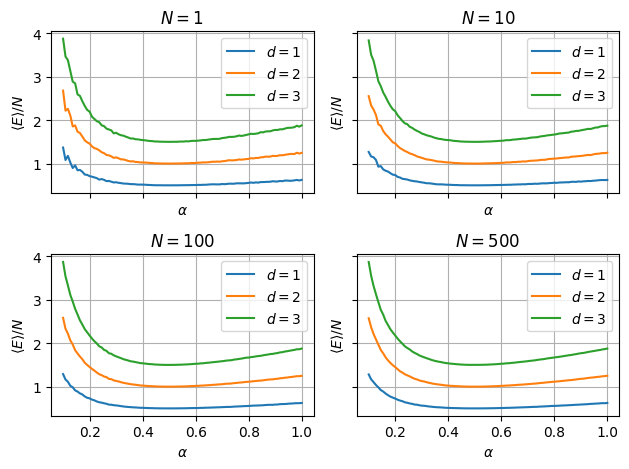

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic import HarmonicParamGrid
from bose_harmonic_jax import (
  log_wavefunction_jax,
  local_energy_jax,
  drift_force_jax,
  HarmonicParams,
)

base_cycles = 100_000
base_dt = 0.05
diffusion_coefficient = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = [1, 10, 100, 500]
dims = [1, 2, 3]

fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
axs = axs.ravel()

for i, n in enumerate(number_particles):
  ax = axs[i]

  time_step = base_dt / np.sqrt(n)

  for j, d in enumerate(dims):

    simulation = MetropolisJAX[HarmonicParams](n, d)
    result = simulation.grid_search_importance(
      log_wavefunction_jax,
      local_energy_jax,
      drift_force_jax,
      param_grid,
      time_step,
      diffusion_coefficient,
      base_cycles,
    )

    energies = result.energies
    ax.plot(alpha_values, energies / n, label=f"$d = {d}$")
    ax.set_title(f"$N = {n}$")
    ax.set(xlabel=r"$\alpha$", ylabel=r"$\langle E \rangle /N$")
    ax.legend()
    ax.grid(True)

    if d == 3:
      min_energy = np.min(energies)
      min_alpha = alpha_values[np.argmin(energies)]
      print(f"Results for N = {n}, d = {d}:")
      print(f"Minimum energy: {min_energy:.3f}")
      print(f"Minimum alpha: {min_alpha:.3f}")
      print(f"Mean accept rate: {np.mean(result.accept_rates):.3f}\n")

plt.tight_layout()
plt.savefig("vmc_bose_harmonic_grid_importance_analytic_numerical.pdf", format="pdf")
plt.show()


## Numerical local energy

Results for N = 1, d = 3:
Minimum energy: 1.495
Minimum alpha: 0.564
Mean accept rate: 0.994

Results for N = 10, d = 3:
Minimum energy: 15.000
Minimum alpha: 0.500
Mean accept rate: 0.996

Results for N = 100, d = 3:
Minimum energy: 150.000
Minimum alpha: 0.500
Mean accept rate: 0.998

Results for N = 500, d = 3:
Minimum energy: 751.273
Minimum alpha: 0.491
Mean accept rate: 0.999



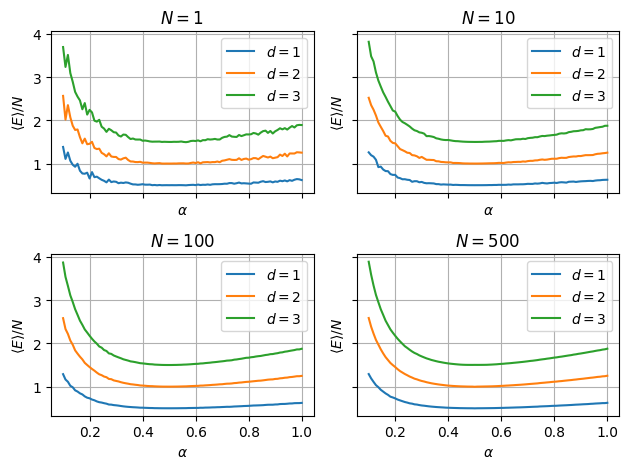

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic import HarmonicParamGrid
from bose_harmonic_jax import (
  log_wavefunction_jax,
  local_energy_numeric_jax,
  drift_force_numeric_jax,
  HarmonicParams,
)

base_cycles = 100_000
base_dt = 0.05
diffusion_coefficient = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = [1, 10, 100, 500]
dims = [1, 2, 3]

fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
axs = axs.ravel()

for i, n in enumerate(number_particles):
  ax = axs[i]

  time_step = base_dt / np.sqrt(n)

  for j, d in enumerate(dims):

    simulation = MetropolisJAX[HarmonicParams](n, d)
    result = simulation.grid_search_importance(
      log_wavefunction_jax,
      local_energy_numeric_jax,
      drift_force_numeric_jax,
      param_grid,
      time_step,
      diffusion_coefficient,
      base_cycles,
    )
    energies = result.energies
    ax.plot(alpha_values, energies / n, label=f"$d = {d}$")
    ax.set_title(f"$N = {n}$")
    ax.set(xlabel=r"$\alpha$", ylabel=r"$\langle E \rangle /N$")
    ax.legend()
    ax.grid(True)

    if d == 3:
      min_energy = np.min(energies)
      min_alpha = alpha_values[np.argmin(energies)]
      print(f"Results for N = {n}, d = {d}:")
      print(f"Minimum energy: {min_energy:.3f}")
      print(f"Minimum alpha: {min_alpha:.3f}")
      print(f"Mean accept rate: {np.mean(result.accept_rates):.3f}\n")

plt.tight_layout()
plt.show()

## Comparison of analytic and numeric approach

Analytic time: 8.73 s
Numeric time: 4.54 s
Numeric is 1.92x faster


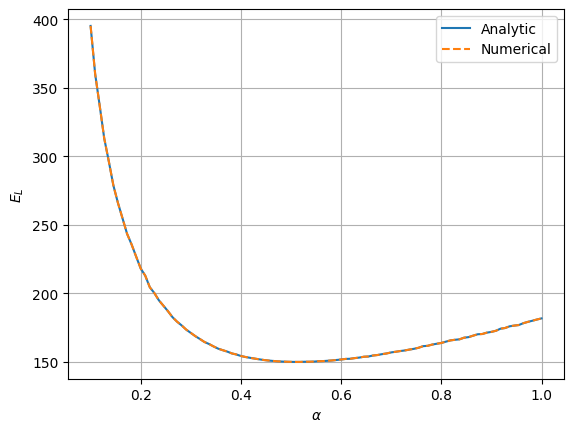

In [ ]:
import time

from matplotlib import pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic import HarmonicParamGrid
from bose_harmonic_jax import (
  log_wavefunction_jax,
  local_energy_jax,
  drift_force_jax,
  drift_force_numeric_jax,
  local_energy_numeric_jax,
  HarmonicParams,
)

cycles = 10_000
time_step = 0.05
diffusion_coefficient = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = 100
dim = 3

simulation = MetropolisJAX[HarmonicParams](number_particles, dim)

# Analytic
start_analytic = time.perf_counter()
result_analytic = simulation.grid_search_importance(
  log_wavefunction_jax,
  local_energy_jax,
  drift_force_jax,
  param_grid,
  time_step,
  diffusion_coefficient,
  cycles,
)
stop_analytic = time.perf_counter()
time_analytic = stop_analytic - start_analytic

# Numeric
start_numeric = time.perf_counter()
result_numeric = simulation.grid_search_importance(
  log_wavefunction_jax,
  local_energy_numeric_jax,
  drift_force_numeric_jax,
  param_grid,
  time_step,
  diffusion_coefficient,
  cycles,
)
stop_numeric = time.perf_counter()
time_numeric = stop_numeric - start_numeric

print(f"Analytic time: {time_analytic:.2f} s")
print(f"Numeric time: {time_numeric:.2f} s")
if time_analytic < time_numeric:
  factor = time_numeric / time_analytic
  print(f"Analytic is {factor:.2f}x faster")
else:
  factor = time_analytic / time_numeric
  print(f"Numeric is {factor:.2f}x faster")

plt.plot(alpha_values, result_analytic.energies, label="Analytic")
plt.plot(alpha_values, result_numeric.energies, label="Numerical", linestyle="dashed")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\langle E \rangle$")
plt.legend()
plt.grid(True)
plt.show()

# Dependence on time step

Results for dt = 0.5
Minimum energy: 514.172
Minimum alpha: 1.000
Mean accept rate: 0.019

Results for dt = 0.1
Minimum energy: 749.280
Minimum alpha: 0.491
Mean accept rate: 0.441

Results for dt = 0.05
Minimum energy: 750.000
Minimum alpha: 0.500
Mean accept rate: 0.843

Results for dt = 0.01
Minimum energy: 750.000
Minimum alpha: 0.500
Mean accept rate: 0.986

Results for dt = 0.005
Minimum energy: 749.959
Minimum alpha: 0.491
Mean accept rate: 0.995

Results for dt = 0.001
Minimum energy: 748.057
Minimum alpha: 0.473
Mean accept rate: 1.000



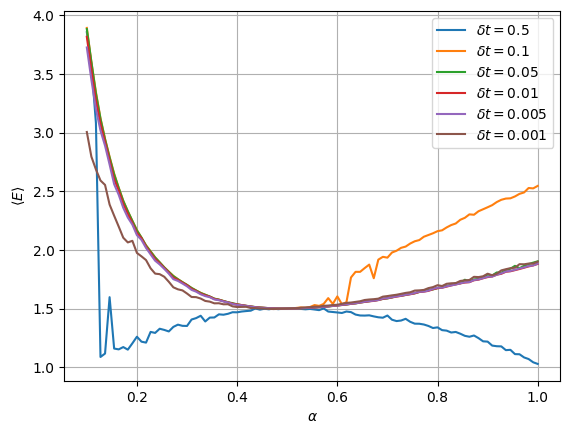

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic import HarmonicParamGrid
from bose_harmonic_jax import (
  log_wavefunction_jax,
  local_energy_jax,
  drift_force_jax,
  HarmonicParams,
)

base_cycles = 10_000
diffusion_coefficient = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = 500
dims = 3

simulation = MetropolisJAX[HarmonicParams](number_particles, dims)

time_steps = [0.1, 0.01, 0.001]
for t in time_steps:

  result = simulation.grid_search_importance(
    log_wavefunction_jax,
    local_energy_jax,
    drift_force_jax,
    param_grid,
    t,
    diffusion_coefficient,
    base_cycles,
  )

  energies = result.energies
  plt.plot(alpha_values, energies / n, label=rf"$\delta t = {t}$")

  min_energy = np.min(energies)
  min_alpha = alpha_values[np.argmin(energies)]
  print(f"Results for dt = {t}")
  print(f"Minimum energy: {min_energy:.3f}")
  print(f"Minimum alpha: {min_alpha:.3f}")
  print(f"Mean accept rate: {np.mean(result.accept_rates):.3f}\n")

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\langle E \rangle$")
plt.legend()
plt.grid(True)
#plt.savefig("vmc_bose_harmonic_grid_importance_analytic_time_step_dependence.pdf", format="pdf")
plt.show()

### Comparison of brute force and importance sampling Metropolis algorith 

Importance: time=3.21s, accept rate=1.00
Brute force: time=7.65s, accept rate=0.72
Importance sampling is 2.38x faster


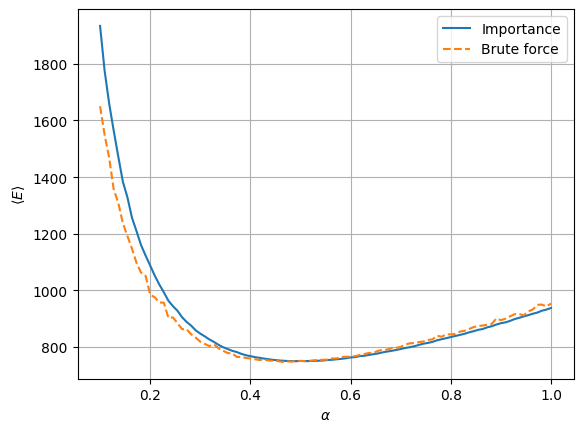

In [ ]:
import time

from matplotlib import pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic_jax import (
  log_wavefunction_jax,
  local_energy_jax,
  drift_force_jax,
  HarmonicParams,
)
from bose_harmonic import HarmonicParamGrid

cycles = 100_000
base_step = 1.0
base_dt = 0.05
diffusion_coefficient = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = 500
dimension = 3
time_step = base_dt / np.sqrt(number_particles)
step_size = base_step / np.sqrt(number_particles)

simulation = MetropolisJAX[HarmonicParams](number_particles, dimension)

start_importance = time.perf_counter()
result_importance = simulation.grid_search_importance(
  log_wavefunction_jax,
  local_energy_jax,
  drift_force_jax,
  param_grid,
  time_step,
  diffusion_coefficient,
  cycles,
)
end_importance = time.perf_counter()
time_importance = end_importance - start_importance

start_brute = time.perf_counter()
result_brute = simulation.grid_search_brute(
  log_wavefunction_jax,
  local_energy_jax,
  param_grid,
  step_size,
  cycles,
)
end_brute = time.perf_counter()
time_brute = end_brute - start_brute

accept_rate_importance = np.mean(result_importance.accept_rates)
accept_rate_brute = np.mean(result_brute.accept_rates)

print(f"Importance: time={time_importance:.2f}s, accept rate={accept_rate_importance:.2f}")
print(f"Brute force: time={time_brute:.2f}s, accept rate={accept_rate_brute:.2f}")
if time_importance < time_brute:
  factor = time_brute / time_importance
  print(f"Importance sampling is {factor:.2f}x faster")
else:
  factor = time_importance / time_brute
  print(f"Brute force sampling is {factor:.2f}x faster")

plt.plot(alpha_values, result_importance.energies / N, label="Importance")
plt.plot(alpha_values, result_brute.energies / N, label="Brute force", linestyle="dashed")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\langle E / N \rangle$")
plt.legend()
plt.grid(True)
plt.savefig("vmc_bose_harmonic_grid_brute_importance_analytic.pdf", format="pdf")
plt.show()